In [1]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

# Import the framework
from nowkit.nowcasting_framework import (
    NowcastConfig,
    DataManager,
    ModelManager,
    EvaluationManager,
    VisualizationManager,
    InferencePipeline
)

# Import model
from sklearn.linear_model import ElasticNet

## 1. Configuration

In [2]:
# Configure ElasticNet experiment
config = NowcastConfig(
    target_variable="gdpc1",
    test_start_date="2005-03-01",
    test_end_date="2010-03-01",
    n_lags=4,
    n_ensemble_models=1,  # Deterministic model, no ensemble needed
    quarterly_only=True
)

print("ElasticNet Regression Configuration:")
print("=" * 60)
for key, value in config.to_dict().items():
    print(f"{key:20s}: {value}")
print("=" * 60)

ElasticNet Regression Configuration:
target              : gdpc1
test_period         : 2005-03-01 to 2010-03-01
lags                : [-2, -1, 0, 1, 2]
n_lags              : 4
n_ensemble          : 1


## 2. Data Loading

In [3]:
# Initialize and load data
data_manager = DataManager(config)
data_manager.load_data().prepare_test_data()

# Display data summary
data_manager.summary()

✓ Loaded data: (913, 25)
✓ Loaded metadata: (24, 8)
✓ Test data prepared: 21 periods


,Metric,Value
0,Total Observations,913
1,Test Periods,21
2,Variables,24
3,Target Variable,gdpc1
4,Missing in Target (%),66.9%


## 3. Model Training and Backtesting

In [4]:
# Configure ElasticNet parameters
# Combines L1 and L2 regularization
elasticnet_params = {
    'alpha': 1e-5,
    'l1_ratio': 0.25,  # 25% L1, 75% L2
    'max_iter': 10000
}

# Create model manager and run backtest
elasticnet_model = ModelManager(ElasticNet, elasticnet_params, config)
elasticnet_model.run_backtest(data_manager)


Running backtest with 1 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed


## 4. Evaluation

In [5]:
# Evaluate model performance
evaluator = EvaluationManager()
evaluator.add_model_results(
    'ElasticNet (α=1e-5, l1=0.25)',
    elasticnet_model.get_predictions(),
    data_manager.actuals,
    config.lags
)

# Display performance metrics
print("\nPERFORMANCE BY VINTAGE:")
print("-" * 60)
display(evaluator.get_performance_table().round(6))

print("\n" + evaluator.summary_report())


PERFORMANCE BY VINTAGE:
------------------------------------------------------------


Model,Vintage,"ElasticNet (α=1e-5, l1=0.25)"
0,-2,0.008215
1,-1,0.007190
2,0,0.006949
3,1,0.007643
4,2,0.004334



MODEL EVALUATION SUMMARY

Model: ElasticNet (α=1e-5, l1=0.25)
  Average RMSE across vintages: 0.006866
  Best vintage: lag=2 (RMSE=0.004334)



## 5. Visualization

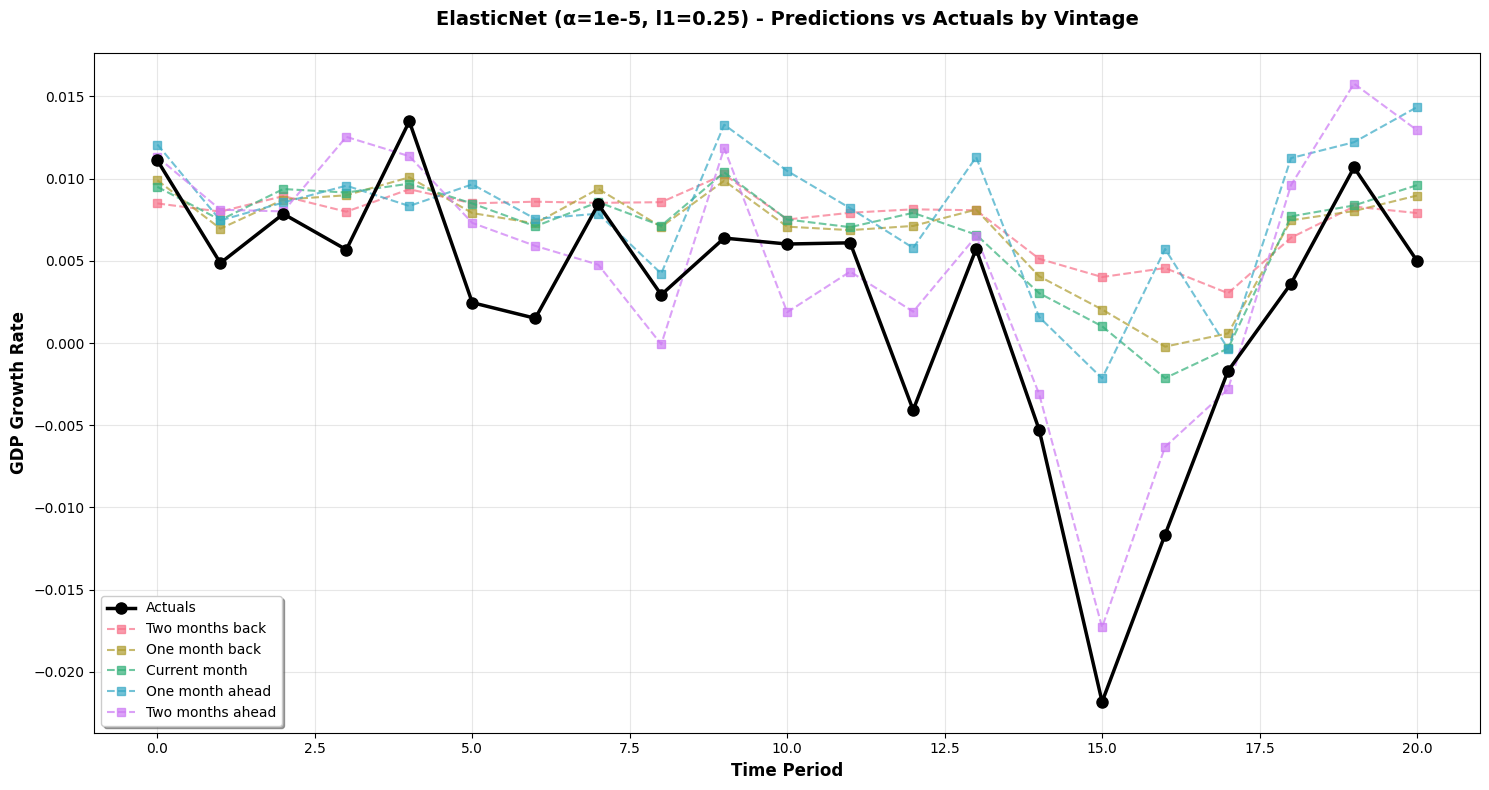

In [6]:
# Create visualization manager
viz = VisualizationManager(evaluator)

# Plot predictions vs actuals
fig1 = viz.plot_predictions_vs_actuals('ElasticNet (α=1e-5, l1=0.25)')
plt.show()

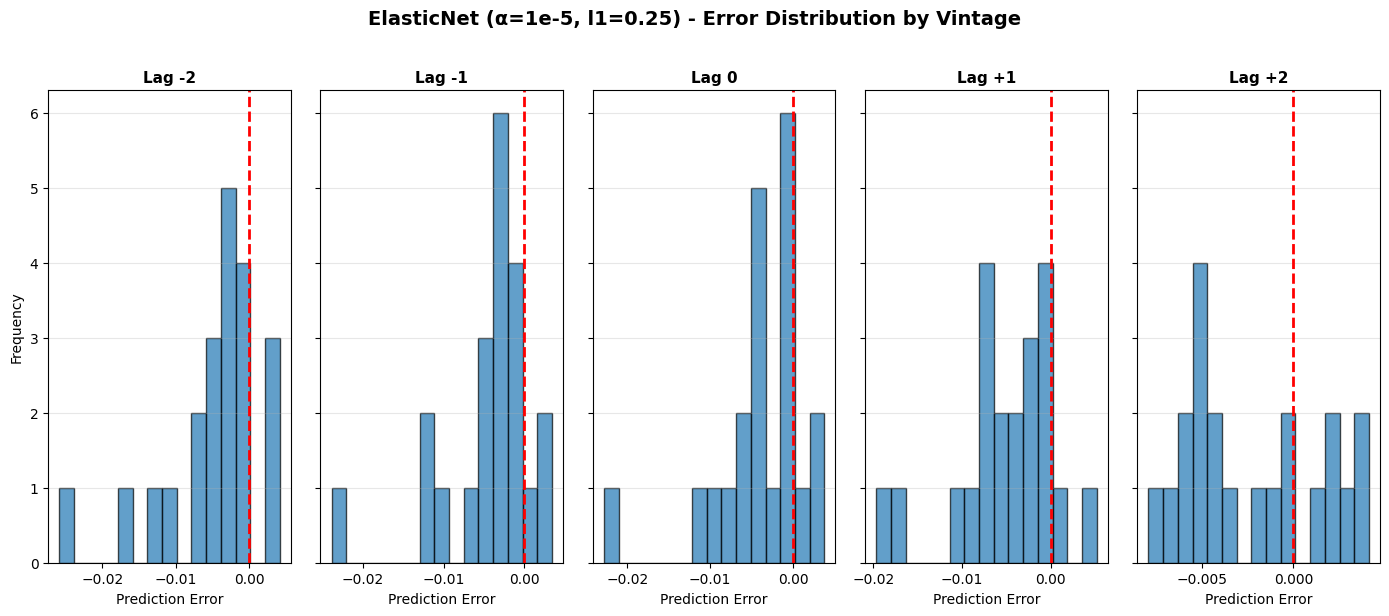

In [7]:
# Plot error distribution
fig2 = viz.plot_error_distribution('ElasticNet (α=1e-5, l1=0.25)')
plt.show()

## 6. Production Inference

In [8]:
# Create inference pipeline
inference = InferencePipeline(elasticnet_model, data_manager, config)

# Predict future quarter
prediction = inference.predict_new_date("2010-06-01")

print("\nFUTURE PREDICTION:")
print("=" * 60)
for key, value in prediction.items():
    print(f"{key:20s}: {value}")


FUTURE PREDICTION:
target_date         : 2010-06-01
prediction          : 0.0073105545413230544
target_variable     : gdpc1
n_models            : 1
model_class         : ElasticNet


## Summary

This notebook implements ElasticNet regression for GDP nowcasting. ElasticNet combines L1 (Lasso) and L2 (Ridge) regularization, which provides both feature selection and coefficient shrinkage. With `l1_ratio=0.25`, the model uses 25% L1 penalty and 75% L2 penalty, balancing sparsity with stability.

The framework approach streamlines the implementation by handling data loading, backtesting across vintages, and evaluation automatically. This makes it easy to experiment with different regularization parameters and compare results across models.

For production use, the InferencePipeline class provides a clean interface for generating predictions on new data.